For several tests and studies it is important to test if the variables in this test are independent of each other. As the independence is directly connected to the correlation between variables (independent variables have correlation of exactly 0) we can test this parameter statistically. So we have a null hypothesis that the correlation is 0, and we are testing against the alternative hypothesis that it significantly differs from that value. There are several tests for this purpose. The most commonly used is the Pearson method, another popular one is the Spearman method. Both are available in the function cor.test().

Create to random variables one of 50 samples taken from the log normal distribution, and the second being
the first + another log normal distribution. Check them for independence using the pearson method, and then using the
spearman method. Compare the results.

In [1]:
set.seed(42)
x <- rlnorm(50)
y <- x + rlnorm(50)

cor.test(x, y, method = "pearson")
cor.test(x, y, method = "spearman")


	Pearson's product-moment correlation

data:  x and y
t = 10.364, df = 48, p-value = 7.763e-14
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.7194872 0.9011605
sample estimates:
      cor 
0.8313437 



	Spearman's rank correlation rho

data:  x and y
S = 6308, p-value = 7.664e-08
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.6970948 


Alternatively we can test for independence by testing if the joint probability distribution between variables that is observed differs significantly from the joint probability created from the marginal probabilities if the variables were independent. This is also a test attributed to Pearson and can be done using the chisq.test() function. As a result of this function we get the expected joint distribution under the parameter expected. The are also more precise tests with this approach like the fisher.test().

For the data in daneSoc test for dependence between gender and employment, gender and relationship status,
and for education level and employment. Check what the expected values would actually be if they were independent.

In [ ]:
A <- read.csv2("Data/daneSoc.csv")
head(A)

(test1 <- chisq.test(x = A$plec, y = A$praca))
fisher.test(x = A$plec, y = A$praca)
test1$expected

,wiek,wyksztalcenie,st.cywilny,plec,praca,cisnienie.skurczowe,cisnienie.rozkurczowe
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
1,70,zawodowe,w zwiazku,mezczyzna,uczen lub pracuje,143,83
2,66,zawodowe,w zwiazku,kobieta,uczen lub pracuje,123,80
3,71,zawodowe,singiel,kobieta,uczen lub pracuje,167,80
4,57,srednie,w zwiazku,mezczyzna,uczen lub pracuje,150,87
5,45,srednie,w zwiazku,kobieta,uczen lub pracuje,130,83
6,48,srednie,w zwiazku,mezczyzna,nie pracuje,138,75



	Pearson's Chi-squared test with Yates' continuity correction

data:  A$plec and A$praca
X-squared = 5.5711, df = 1, p-value = 0.01826



	Fisher's Exact Test for Count Data

data:  A$plec and A$praca
p-value = 0.0112
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.1199709 0.8308932
sample estimates:
odds ratio 
 0.3386347 


,nie pracuje,uczen lub pracuje
kobieta,14.01961,40.98039
mezczyzna,37.98039,111.01961


In [3]:
(test2 <- chisq.test(x = A$plec, y = A$st.cywilny))
fisher.test(x = A$plec, y = A$st.cywilny)
test2$expected


	Pearson's Chi-squared test with Yates' continuity correction

data:  A$plec and A$st.cywilny
X-squared = 2.7227, df = 1, p-value = 0.09893



	Fisher's Exact Test for Count Data

data:  A$plec and A$st.cywilny
p-value = 0.07918
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.9083788 3.7652618
sample estimates:
odds ratio 
  1.821107 


,singiel,w zwiazku
kobieta,32.35294,22.64706
mezczyzna,87.64706,61.35294


In [4]:
(test3 <- chisq.test(x = A$wyksztalcenie, y = A$praca))
fisher.test(x = A$wyksztalcenie, y = A$praca)
test3$expected


	Pearson's Chi-squared test

data:  A$wyksztalcenie and A$praca
X-squared = 3.0109, df = 3, p-value = 0.3899



	Fisher's Exact Test for Count Data

data:  A$wyksztalcenie and A$praca
p-value = 0.3947
alternative hypothesis: two.sided


,nie pracuje,uczen lub pracuje
podstawowe,23.705882,69.29412
srednie,14.019608,40.98039
wyzsze,8.666667,25.33333
zawodowe,5.607843,16.39216


Now we will start to analyze information that changes in time. Firstly we will focus on analysis connected to survival. So we have a patient that had a severe desease (like cancer) and after an operation they are cured, but there is always a chance of remission. Observing such patients will lead to two kinds of data, those were after some time there was a remission, and those who do not have a remission yet, but it is still possible for it to happen in the future (these types we all censored, as we have only partial information). To model this we will use the library survival. The data has to be properly modeled and for that purpose we use the class Surv(). The first parameter in this class represents the time of observation till the remission, the second is a logical parameter that recognises which observations are censored.

For data in DaneO.csv create a vector of information of time without remission using the class Surv, with
respect to the information if a remission happened.

In [5]:
library(survival)
install.packages("survminer")
library(survminer)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘litedown’, ‘corrplot’, ‘car’, ‘markdown’, ‘png’, ‘jpeg’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘exactRankTests’, ‘mvtnorm’, ‘gridtext’, ‘ggpubr’, ‘gridExtra’, ‘maxstat’, ‘ggtext’


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




In [ ]:
B <- read.csv2("Data/daneO.csv")
head(B)

remission_flag <- as.numeric(B$Niepowodzenia == "wznowa")
(surv_obj <- Surv(time = B$Okres.bez.wznowy, event = remission_flag))

,Wiek,Rozmiar.guza,Wezly.chlonne,Nowotwor,Receptory.estrogenowe,Receptory.progesteronowe,Niepowodzenia,Okres.bez.wznowy,VEGF
,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>
1,29,1,0,2,(-),(++),brak,22,914
2,29,1,0,2,(++),(++),brak,53,1118
3,30,1,1,2,(-),(+),brak,38,630
4,32,1,0,3,(++),(++),brak,26,1793
5,32,2,0,NA,(-),(++),brak,19,963
6,33,1,1,3,(-),(++),wznowa,36,2776


 [1] 22+ 53+ 38+ 26+ 19+ 36  33+ 38+ 38  37+ 47+ 40  30  16  44+ 27+ 36+ 19+ 41+
[20] 18+ 41  29  47+ 47+ 53+ 33+ 30+ 39+ 38+ 47+ 44+ 48+ 33+ 36+ 43  53+ 38+ 33+
[39] 41+ 54+ 51+ 23+ 42+ 42+ 45+ 51+ 42+ 36+ 38+ 28+ 27+ 31+ 47+ 33+ 42+ 38+ 34+
[58] 21  34+ 36+ 26+ 36+ 39+ 39+ 49+ 28+ 19  29+ 46+ 33+ 45+ 39+ 43+ 49+ 41+ 27+
[77] 33+ 33+ 36+ 50+ 52+ 10  49+ 30+ 30+ 42+ 47+ 48  35+ 48+ 43+ 50  30+ 36+ 29+
[96] NA+ 46+

Having this data we can estimate a survival curve using the function survfit(). We supply it with a formula where the left side of the formula should be of the Surv() class. If the right side is omitted we get the most general case of the survival curve. If the right side is a qualitative variable, we will get a set of curves, each calculated with respect to the values in the qualitative variable.

For the data from the previous task create a survival curve using the function survfit, plot it and plot the data
with respect to the type of cancer.

Call: survfit(formula = surv_obj ~ 1)

   1 observation deleted due to missingness 
      n events median 0.95LCL 0.95UCL
[1,] 96     13     NA      NA      NA

Call: survfit(formula = surv_obj ~ B$Nowotwor)

   11 observations deleted due to missingness 
              n events median 0.95LCL 0.95UCL
B$Nowotwor=1  7      0     NA      NA      NA
B$Nowotwor=2 53      4     NA      NA      NA
B$Nowotwor=3 26      9     50      41      NA

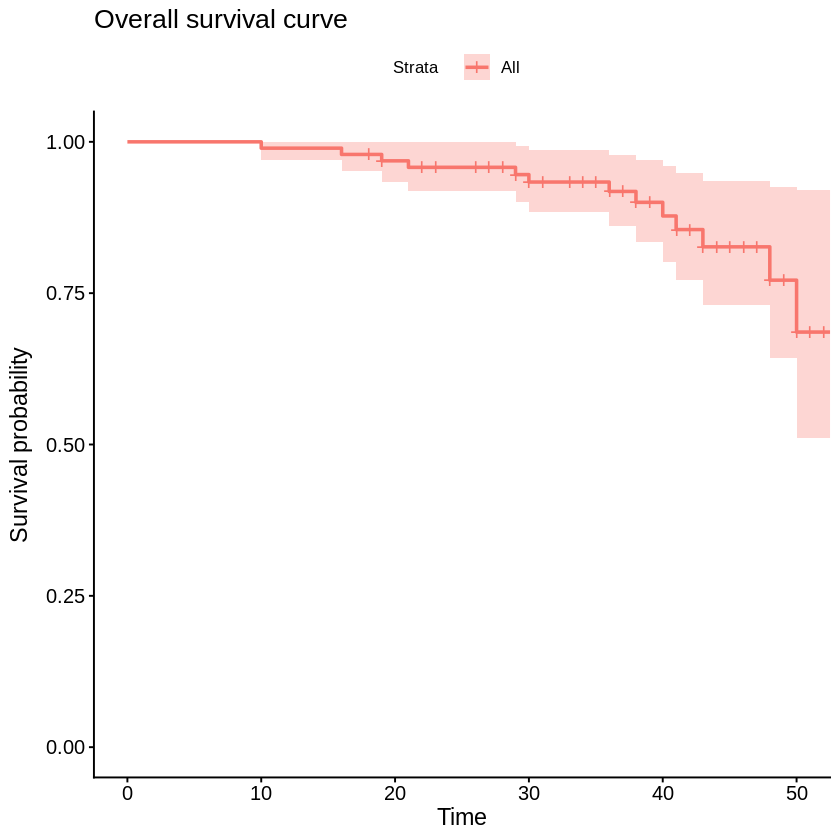

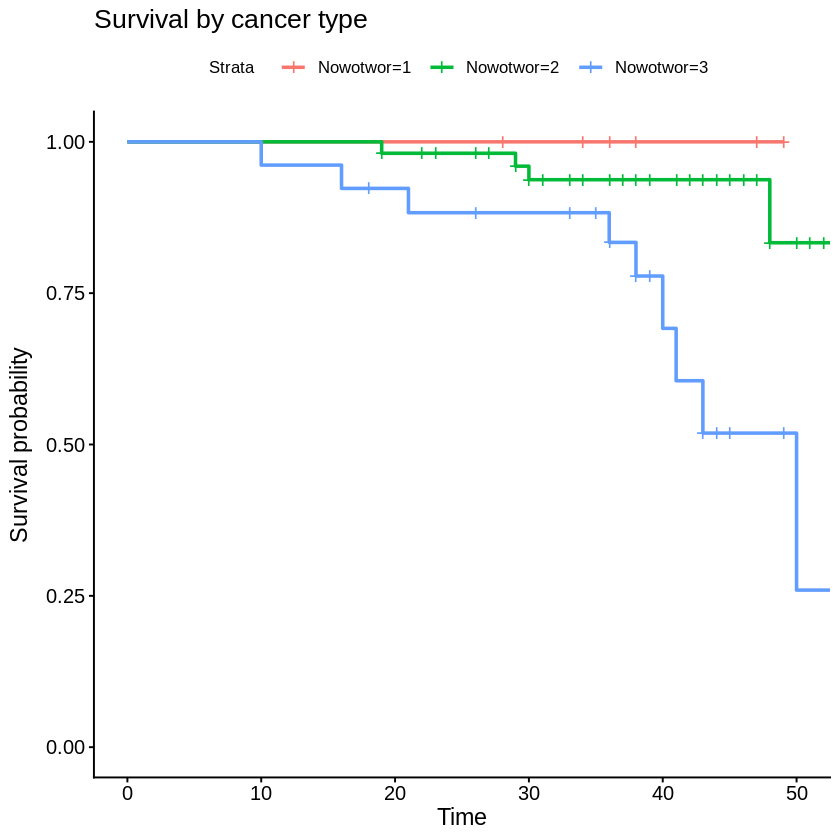

In [7]:
(fit_overall <- survfit(surv_obj ~ 1))
ggsurvplot(fit_overall, data = B, title = "Overall survival curve")

(fit_by_type <- survfit(surv_obj ~ B$Nowotwor))
ggsurvplot(fit_by_type, data = B, title = "Survival by cancer type")

When creating different survival curves depending on a qulitative variable, we would also like to test for possible differences between these variables. The proper test for this purpose is the Mantel-Heanszel test and it is implemented if the survdiff() function.

Test if the survival curves diffrentiate signifficantly using the survdiff function.

In [8]:
survdiff(surv_obj ~ B$Nowotwor)

Call:
survdiff(formula = surv_obj ~ B$Nowotwor)

n=86, 11 observations deleted due to missingness.

              N Observed Expected (O-E)^2/E (O-E)^2/V
B$Nowotwor=1  7        0    0.913     0.913     0.991
B$Nowotwor=2 53        4    8.532     2.408     7.091
B$Nowotwor=3 26        9    3.554     8.344    11.552

 Chisq= 11.7  on 2 degrees of freedom, p= 0.003 

Of course we may want to find how survival differs not only based on qualitative variables but also quantitative variables, or a mix of both. For that goal we create what is called a hazard function which is supposed to calculate the probability of living past a certain age on the condition we lived till that age. This is called the Cox model. The parameters of this function can be estimated using the coxph() function. When we have the parameters the function cox.zph() which will plot the models.

Create a Cox survival model for the connection of time to reamission to the type of cancer and age. Plot the
results.

Call:
coxph(formula = surv_obj ~ B$Nowotwor + B$Wiek)

               coef exp(coef) se(coef)      z       p
B$Nowotwor  1.75372   5.77607  0.59566  2.944 0.00324
B$Wiek     -0.05632   0.94524  0.04340 -1.297 0.19447

Likelihood ratio test=12.17  on 2 df, p=0.002282
n= 86, number of events= 13 
   (11 observations deleted due to missingness)

           chisq df    p
B$Nowotwor 0.710  1 0.40
B$Wiek     0.119  1 0.73
GLOBAL     0.737  2 0.69

`geom_smooth()` using formula = 'y ~ x'


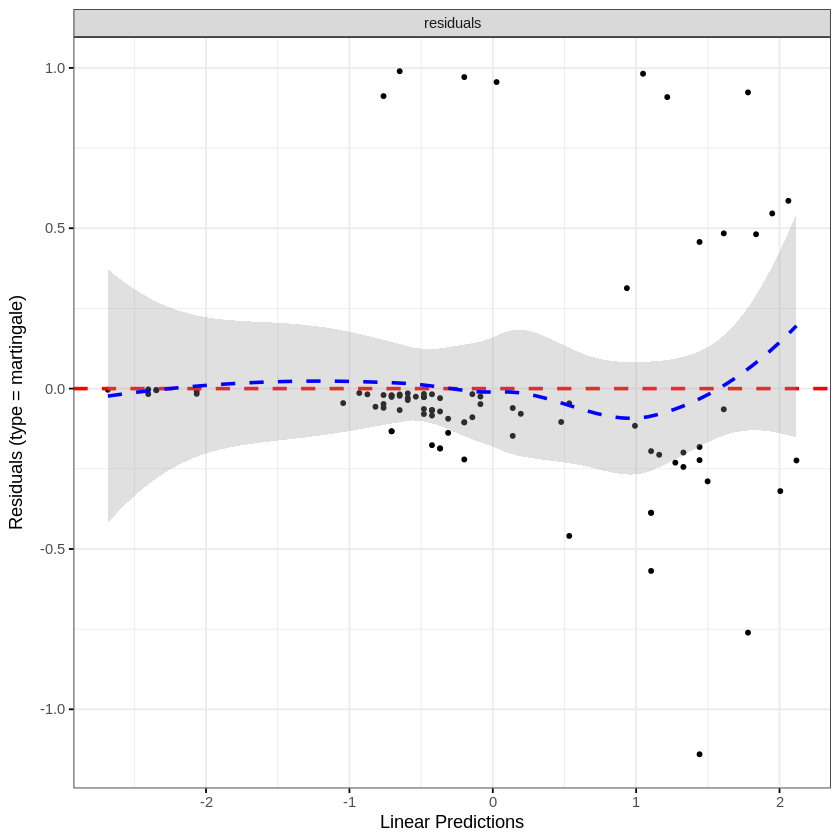

In [9]:
(cox_model <- coxph(surv_obj ~ B$Nowotwor + B$Wiek))

cox.zph(cox_model)
ggcoxdiagnostics(cox_model)